**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

# What drives the price of a car?

![](images/kurt.jpeg)

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
df = pd.read_csv('data/vehicles.csv')

In [17]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [35]:
df_cleaned = df.dropna() ## drop all rows with null values
df_cleaned = df_cleaned[df_cleaned['price'] > 0] ## eliminate rows with 0 price
df_cleaned.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al
268,7315946365,birmingham,9000,2008.0,mazda,miata mx-5,excellent,4 cylinders,gas,56700.0,clean,automatic,JM1NC25F570128735,rwd,compact,convertible,white,al
337,7315354216,birmingham,8950,2011.0,ford,f-150,excellent,6 cylinders,gas,164000.0,clean,automatic,1FTMF1CM6BKD55331,fwd,full-size,truck,white,al
338,7315349921,birmingham,4000,1972.0,mercedes-benz,benz,fair,6 cylinders,gas,88100.0,clean,automatic,1.14023E+13,rwd,full-size,coupe,silver,al


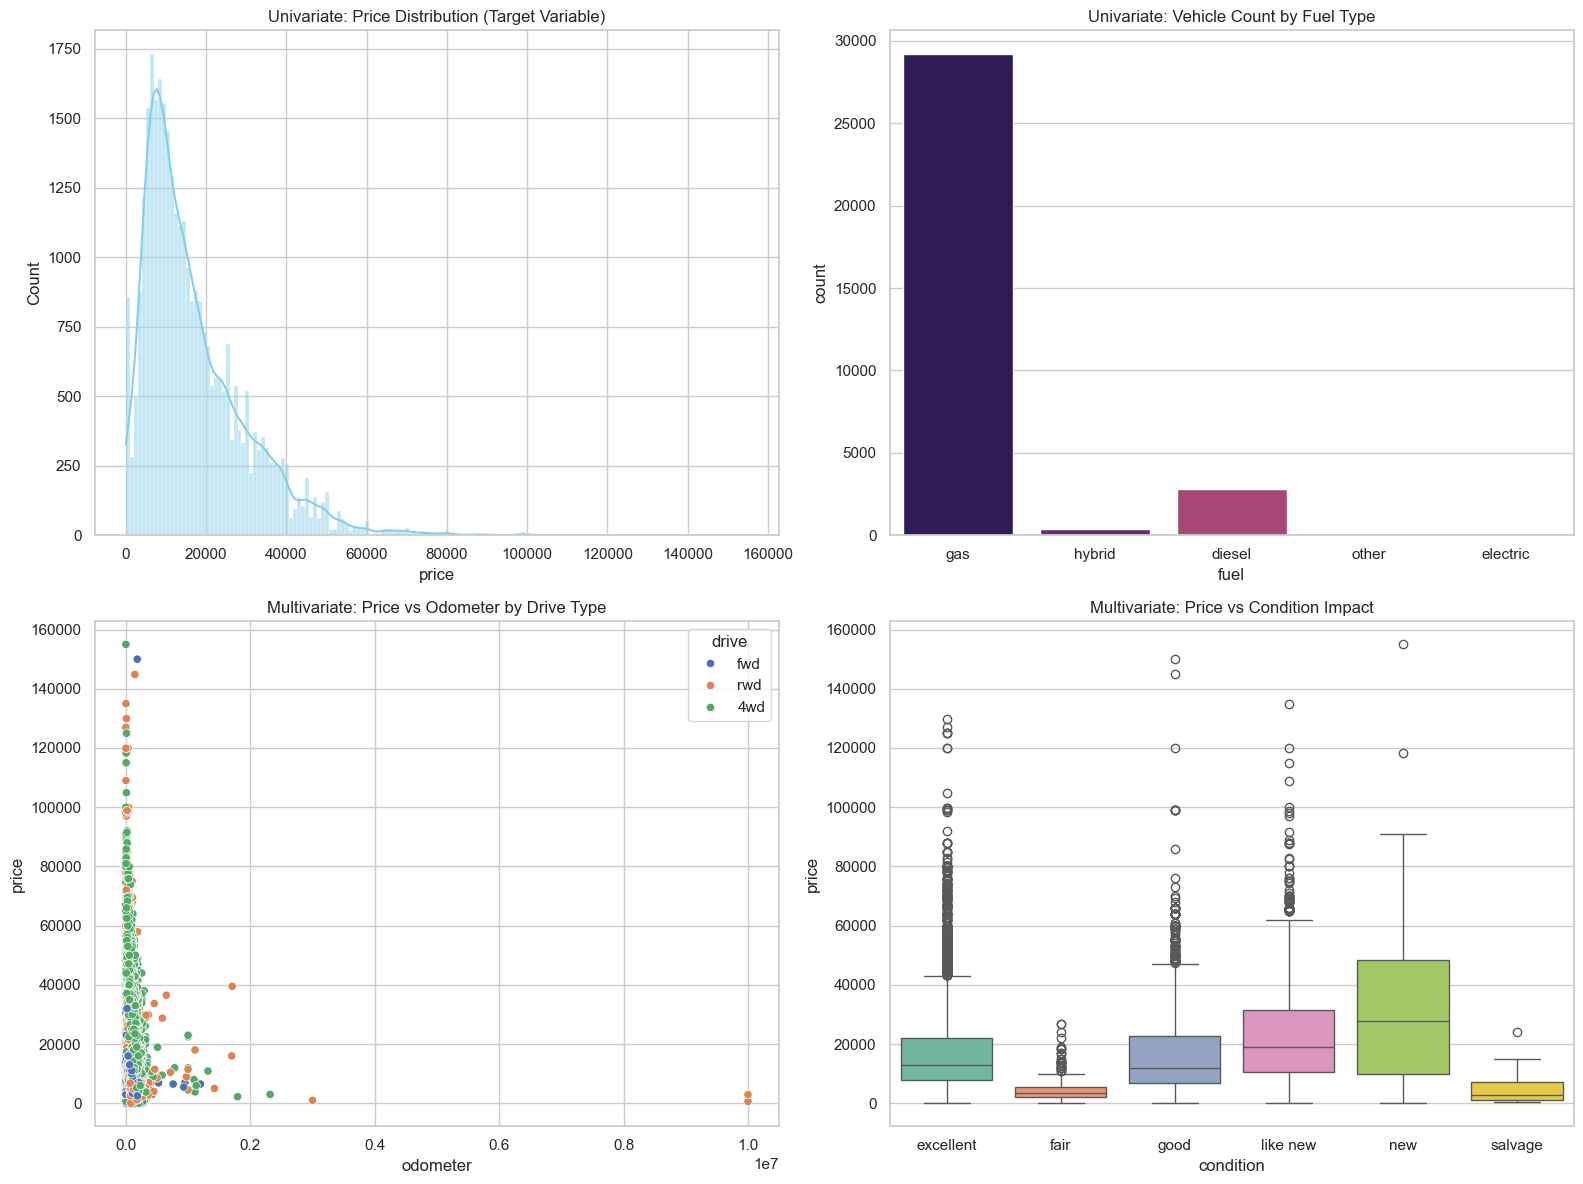

In [34]:
def perform_eda(data):
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Univariate Analysis: Price Distribution
    sns.histplot(data['price'], kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Univariate: Price Distribution (Target Variable)')

    # Univariate Analysis: Categorical Counts (e.g., Fuel Type)
    sns.countplot(x='fuel', data=data, ax=axes[0, 1], palette='magma', hue='fuel', legend=False)
    axes[0, 1].set_title('Univariate: Vehicle Count by Fuel Type')

    # Multivariate Analysis: Price vs. Odometer by Drive Type
    sns.scatterplot(x='odometer', y='price', hue='drive', data=data, ax=axes[1, 0])
    axes[1, 0].set_title('Multivariate: Price vs Odometer by Drive Type')

    # Multivariate Analysis: Price vs. Condition (Boxplot)
    sns.boxplot(x='condition', y='price', data=data, ax=axes[1, 1], hue='condition', legend=False, palette='Set2')
    axes[1, 1].set_title('Multivariate: Price vs Condition Impact')

    plt.tight_layout()
    plt.show()

perform_eda(df_cleaned)

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [36]:
def prepare_data(data):
    data = data.drop(columns=['VIN', 'region', 'state'])
    data = data[data['price'] > 100]
    current_year = 2026
    data['age'] = current_year - data['year']
    data = data.drop(columns=['year'])
    data = data.dropna(subset=['price'])
    return data

df_cleaned = prepare_data(df_cleaned)

In [37]:
# Define feature groups
numeric_features = ['age', 'odometer']
categorical_features = ['model', 'condition', 'cylinders', 'fuel', 'title_status', 
                        'transmission', 'drive', 'size', 'type', 'paint_color']

X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [38]:
# Preprocessing: Impute missing values and scale/encode
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [39]:

# Core Pipeline with Linear Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [42]:
y_pred = model_pipeline.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

R-squared Score: 0.6882
Mean Squared Error: 53391480.85


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [43]:
regressor = model_pipeline.named_steps['regressor']
onehot_cols = model_pipeline.named_steps['preprocessor'].transformers_[1][1]\
              .named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(onehot_cols)

coeffs = pd.Series(regressor.coef_, index=feature_names).sort_values(ascending=False)
print("\nTop 5 Features Driving Higher Prices:")
print(coeffs.head(5))


Top 5 Features Driving Higher Prices:
model_928                 123150.258350
model_benz sprinter       114707.700054
model_nova yenko deuce    114299.670461
model_sedan               113089.789394
model_wagon               112391.219816
dtype: float64
